In [3]:
import sys
sys.path.append('/workspaces/BlizzardX')

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import joblib
import os

In [5]:
data = pd.read_csv('/workspaces/BlizzardX/Data/cleaned_data.csv')  # Update path if needed
data['DATE'] = pd.to_datetime(data['DATE'])

In [4]:
# 2. Define cutoff date
cutoff_date = pd.to_datetime('2025-01-31')

# 3. Split the data
train_data = data[data['DATE'] <= cutoff_date].copy()
future_data = data[data['DATE'] > cutoff_date].copy()

In [5]:
# 4. Check split (optional)
print(f"Train data shape: {train_data.shape}")
print(f"Future data shape: {future_data.shape}")

Train data shape: (53516, 12)
Future data shape: (490, 12)


In [8]:
# 5. Save to two different CSVs
output_folder = '/workspaces/BlizzardX/Data/'  # Example: '/workspaces/BlizzardX/Data/'
os.makedirs(output_folder, exist_ok=True)

train_data.to_csv(os.path.join(output_folder, 'train_data.csv'), index=False)
future_data.to_csv(os.path.join(output_folder, 'future_data.csv'), index=False)

print("\n✅ Successfully created 'train_data.csv' and 'future_data.csv'!")


✅ Successfully created 'train_data.csv' and 'future_data.csv'!


In [11]:
train_df = pd.read_csv('/workspaces/BlizzardX/Data/train_data.csv')  # Update your path
train_df['DATE'] = pd.to_datetime(train_df['DATE'])  # Ensure DATE is datetime

In [13]:
from src.Model.feature_engineering import FeatureEngineering 
fe = FeatureEngineering(train_df)
train_df = fe.apply_all_features()

In [14]:
print(f"✅ Train data after feature engineering: {train_df.shape}")
print(train_df.columns)

✅ Train data after feature engineering: (53516, 45)
Index(['DATE', 'Station_ID', 'LATITUDE', 'LONGITUDE', 'ELEVATION', 'NAME',
       'Season', 'TMIN', 'TMAX', 'PRCP', 'SNOW', 'SNWD', 'Station_Location',
       'Station_Lat_Long_Interaction', 'Day_of_Week', 'Day_of_Year', 'Month',
       'Temp_Diff', 'Rolling_Mean_TMIN_7', 'Rolling_10thPercentile_TMIN_7',
       'Rolling_Mean_TMIN_30', 'Rolling_Max_TMIN_30', 'Rolling_Min_TMIN_30',
       'TMIN_Rolling_30_Diff', 'EWMA_TMIN_7', 'EWMA_TMIN_30',
       'Seasonal_TMIN_Anomaly', 'TMIN_Lag1', 'SnowyDay', 'SnowyDaysCount_7',
       'Cumulative_SnowDepth_7', 'Rolling_Sum_SNWD_7', 'SNWD_Lag1',
       'SNWD_Lag2', 'Cumulative_Snowfall_Lag7', 'SNWD_TMIN_Interaction',
       'Snowfall_Intensity', 'SNWD_Snowfall_Diff', 'PRCP_Lag1', 'PRCP_Lag2',
       'Cumulative_Precipitation_7', 'Rolling_Sum_PRCP_14',
       'TMAX_PRCP_Interaction', 'TMIN_SNOW_Interaction',
       'PRCP_SNOW_Interaction'],
      dtype='object')


In [8]:
future_df = pd.read_csv('/workspaces/BlizzardX/Data/future_data.csv')
future_df['DATE'] = pd.to_datetime(future_df['DATE'])

In [38]:

# Check date range
print(f"✅ Data Date Range: {future_df['DATE'].min()} to {future_df['DATE'].max()}")

# Show first few rows
print(future_df.head())

✅ Data Date Range: 2025-02-01 00:00:00 to 2025-05-09 00:00:00
        DATE   Station_ID  LATITUDE  LONGITUDE  ELEVATION          NAME  \
0 2025-02-01  USC00272302   42.8267   -71.6261       73.2  NH E MILFORD   
1 2025-02-02  USC00272302   42.8267   -71.6261       73.2  NH E MILFORD   
2 2025-02-03  USC00272302   42.8267   -71.6261       73.2  NH E MILFORD   
3 2025-02-04  USC00272302   42.8267   -71.6261       73.2  NH E MILFORD   
4 2025-02-05  USC00272302   42.8267   -71.6261       73.2  NH E MILFORD   

   Season  TMIN  TMAX  PRCP  SNOW   SNWD  
0  Winter -10.0   1.7  17.8  38.0  102.0  
1  Winter -19.4  -3.9   0.0   0.0  102.0  
2  Winter -19.4  -5.0   2.8  30.0  127.0  
3  Winter  -7.2   6.1   0.0   0.0  127.0  
4  Winter -11.1   3.3   0.0   0.0  102.0  


In [16]:
future_df.head()

,DATE,ID,LATITUDE,LONGITUDE,ELEVATION,NAME,Season,TMIN,TMAX,PRCP,SNOW,SNWD
0,2025-02-01,USC00272302,42.8267,-71.6261,73.2,NH E MILFORD,Winter,-10.0,1.7,17.8,38.0,102.0
1,2025-02-02,USC00272302,42.8267,-71.6261,73.2,NH E MILFORD,Winter,-19.4,-3.9,0.0,0.0,102.0
2,2025-02-03,USC00272302,42.8267,-71.6261,73.2,NH E MILFORD,Winter,-19.4,-5.0,2.8,30.0,127.0
3,2025-02-04,USC00272302,42.8267,-71.6261,73.2,NH E MILFORD,Winter,-7.2,6.1,0.0,0.0,127.0
4,2025-02-05,USC00272302,42.8267,-71.6261,73.2,NH E MILFORD,Winter,-11.1,3.3,0.0,0.0,102.0


In [29]:
print(future_df.columns)

Index(['DATE', 'Station_ID', 'LATITUDE', 'LONGITUDE', 'ELEVATION', 'NAME',
       'Season', 'TMIN', 'TMAX', 'PRCP', 'SNOW', 'SNWD'],
      dtype='object')


In [12]:
# Select last 30 days from train
january_tail = train_df[train_df['DATE'] >= '2025-01-01'].copy()

print(f"✅ January tail shape: {january_tail.shape}")
print(f"✅ February data shape: {future_df.shape}")

✅ January tail shape: (155, 12)
✅ February data shape: (490, 12)


In [13]:
# Before concatenating
future_df = future_df.rename(columns={'ID': 'Station_ID'})

# Then stack together
combined_df = pd.concat([january_tail, future_df], axis=0).reset_index(drop=True)

# Important: Keep track of Feb starting index
february_start_idx = combined_df[combined_df['DATE'] >= '2025-02-01'].index[0]


In [ ]:
from src.Model.feature_engineering import FeatureEngineering

# Apply feature engineering
fe = FeatureEngineering(combined_df)
combined_df = fe.apply_all_features()

# After feature engineering, split back
future_features_df = combined_df.iloc[february_start_idx:].reset_index(drop=True)

print(f"✅ Future features for February ready: {future_features_df.shape}")

In [23]:
# Define non-feature columns
non_feature_cols = ['DATE', 'Station_ID', 'NAME', 'Station_Location', 'TMIN']

# Select only feature columns
feature_cols = [col for col in future_features_df.columns if col not in non_feature_cols]

# Prepare X for prediction
X_future = future_features_df[feature_cols]

print(f"✅ X_future shape ready for prediction: {X_future.shape}")

✅ X_future shape ready for prediction: (490, 40)


In [27]:
# 1. Check if 'Season' is still object
print(X_future['Season'].dtype)

# 2. Map Season to numeric
season_mapping = {'Winter': 0, 'Spring': 1, 'Summer': 2, 'Fall': 3}

X_future['Season'] = X_future['Season'].map(season_mapping)

# 3. Double-check types
print(X_future.dtypes)


int64
LATITUDE                         float64
LONGITUDE                        float64
ELEVATION                        float64
Season                           float64
TMAX                             float64
PRCP                             float64
SNOW                             float64
SNWD                             float64
Station_Lat_Long_Interaction     float64
Day_of_Week                        int32
Day_of_Year                        int32
Month                              int32
Temp_Diff                        float64
Rolling_Mean_TMIN_7              float64
Rolling_10thPercentile_TMIN_7    float64
Rolling_Mean_TMIN_30             float64
Rolling_Max_TMIN_30              float64
Rolling_Min_TMIN_30              float64
TMIN_Rolling_30_Diff             float64
EWMA_TMIN_7                      float64
EWMA_TMIN_30                     float64
Seasonal_TMIN_Anomaly            float64
TMIN_Lag1                        float64
SnowyDay                           int64
SnowyDaysC

/tmp/ipykernel_5368/3139565218.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_future['Season'] = X_future['Season'].map(season_mapping)


In [24]:
tmin_model = joblib.load('/workspaces/BlizzardX/Notebooks/models/xgboost_tmin_feature_model.pkl')

In [31]:
# 1. Add dummy Cold_Event column
X_future['Cold_Event'] = 0

# 2. Predict TMIN
predicted_tmin = tmin_model.predict(X_future)

# 3. Attach prediction back
future_features_df['Predicted_TMIN'] = predicted_tmin

# 4. View results
print(future_features_df[['DATE', 'Station_ID', 'Predicted_TMIN']].head())


        DATE   Station_ID  Predicted_TMIN
0 2025-02-01  USC00272302      -10.080731
1 2025-02-02  USC00272302      -19.059572
2 2025-02-03  USC00272302      -18.761526
3 2025-02-04  USC00272302       -7.533619
4 2025-02-05  USC00272302      -11.229667


/tmp/ipykernel_5368/1056926609.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_future['Cold_Event'] = 0


In [32]:
# Calculate 10th percentile of Predicted_TMIN
predicted_tmin_10th = future_features_df['Predicted_TMIN'].quantile(0.10)

print(f"✅ 10th percentile cutoff for Predicted TMIN: {predicted_tmin_10th:.2f}°C")

# Apply Cold Event Detection
future_features_df['Cold_Event'] = (future_features_df['Predicted_TMIN'] <= predicted_tmin_10th).astype(int)

# Create final table
final_prediction_df = future_features_df[['DATE', 'Station_ID', 'Predicted_TMIN', 'Cold_Event']]

# Display sample
print(final_prediction_df.head(10))


✅ 10th percentile cutoff for Predicted TMIN: -16.84°C
        DATE   Station_ID  Predicted_TMIN  Cold_Event
0 2025-02-01  USC00272302      -10.080731           0
1 2025-02-02  USC00272302      -19.059572           1
2 2025-02-03  USC00272302      -18.761526           1
3 2025-02-04  USC00272302       -7.533619           0
4 2025-02-05  USC00272302      -11.229667           0
5 2025-02-06  USC00272302      -16.018587           0
6 2025-02-07  USC00272302      -13.935369           0
7 2025-02-08  USC00272302      -12.673308           0
8 2025-02-09  USC00272302      -11.558934           0
9 2025-02-10  USC00272302       -8.768932           0


### Evaluation

In [33]:
actual_future_df = pd.read_csv('/workspaces/BlizzardX/Data/future_data.csv')  # Update path if needed
actual_future_df['DATE'] = pd.to_datetime(actual_future_df['DATE'])

# If needed, rename ID -> Station_ID for consistency
actual_future_df = actual_future_df.rename(columns={'ID': 'Station_ID'})

print(f"✅ Loaded actual February data: {actual_future_df.shape}")

✅ Loaded actual February data: (490, 12)


In [34]:
# Merge predictions with actual TMIN based on DATE + Station_ID
merged_df = pd.merge(
    future_features_df[['DATE', 'Station_ID', 'Predicted_TMIN', 'Cold_Event']],
    actual_future_df[['DATE', 'Station_ID', 'TMIN']],
    on=['DATE', 'Station_ID'],
    how='inner'
)

# Rename for clarity
merged_df = merged_df.rename(columns={'TMIN': 'Actual_TMIN'})

print(f"✅ Merged Data Shape: {merged_df.shape}")
print(merged_df.head())

✅ Merged Data Shape: (490, 5)
        DATE   Station_ID  Predicted_TMIN  Cold_Event  Actual_TMIN
0 2025-02-01  USC00272302      -10.080731           0        -10.0
1 2025-02-02  USC00272302      -19.059572           1        -19.4
2 2025-02-03  USC00272302      -18.761526           1        -19.4
3 2025-02-04  USC00272302       -7.533619           0         -7.2
4 2025-02-05  USC00272302      -11.229667           0        -11.1


In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Regression Evaluation for TMIN
mae = mean_absolute_error(merged_df['Actual_TMIN'], merged_df['Predicted_TMIN'])
rmse = np.sqrt(mean_squared_error(merged_df['Actual_TMIN'], merged_df['Predicted_TMIN']))

print(f"✅ TMIN Prediction Evaluation:")
print(f"MAE: {mae:.2f} °C")
print(f"RMSE: {rmse:.2f} °C")

✅ TMIN Prediction Evaluation:
MAE: 0.43 °C
RMSE: 0.71 °C


In [36]:
# Calculate 10th percentile cutoff on Actual_TMIN
actual_tmin_10th = merged_df['Actual_TMIN'].quantile(0.10)

# Create Actual Cold Event labels
merged_df['Actual_Cold_Event'] = (merged_df['Actual_TMIN'] <= actual_tmin_10th).astype(int)

print(f"✅ 10th percentile cutoff for Actual TMIN: {actual_tmin_10th:.2f}°C")

✅ 10th percentile cutoff for Actual TMIN: -17.20°C


In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Classification Metrics
accuracy = accuracy_score(merged_df['Actual_Cold_Event'], merged_df['Cold_Event'])
precision = precision_score(merged_df['Actual_Cold_Event'], merged_df['Cold_Event'])
recall = recall_score(merged_df['Actual_Cold_Event'], merged_df['Cold_Event'])
f1 = f1_score(merged_df['Actual_Cold_Event'], merged_df['Cold_Event'])

print(f"✅ Cold Event Prediction Evaluation:")
print(f"Accuracy: {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall: {recall:.2%}")
print(f"F1 Score: {f1:.2%}")


✅ Cold Event Prediction Evaluation:
Accuracy: 99.39%
Precision: 97.96%
Recall: 96.00%
F1 Score: 96.97%


### March-April Prediction

In [40]:
# Filter March and April data
march_april_df = future_df[
    (future_df['DATE'] >= '2025-03-01') & (future_df['DATE'] <= '2025-04-30')
].copy()

print(f"✅ March-April data shape: {march_april_df.shape}")
print(march_april_df[['DATE', 'Station_ID', 'TMIN']].head())


✅ March-April data shape: (305, 12)
         DATE   Station_ID  TMIN
28 2025-03-01  USC00272302  -1.7
29 2025-03-02  USC00272302 -11.7
30 2025-03-03  USC00272302 -14.4
31 2025-03-04  USC00272302 -12.2
32 2025-03-05  USC00272302 -12.2


In [41]:
from src.Model.feature_engineering import FeatureEngineering

# Apply feature engineering
fe_march_april = FeatureEngineering(march_april_df)
march_april_features_df = fe_march_april.apply_all_features()

print(f"✅ March-April features shape: {march_april_features_df.shape}")


✅ March-April features shape: (305, 45)


In [42]:
# Define non-feature columns
non_feature_cols = ['DATE', 'Station_ID', 'NAME', 'Station_Location', 'TMIN']

# Select feature columns
feature_cols = [col for col in march_april_features_df.columns if col not in non_feature_cols]

# Prepare X for March-April prediction
X_march_april_future = march_april_features_df[feature_cols]

# Map Season if needed (if object type)
if X_march_april_future['Season'].dtype == 'object':
    season_mapping = {'Winter': 0, 'Spring': 1, 'Summer': 2, 'Fall': 3}
    X_march_april_future['Season'] = X_march_april_future['Season'].map(season_mapping)

# Add dummy Cold_Event to match model's expected features
X_march_april_future['Cold_Event'] = 0

print(f"✅ X_march_april_future shape: {X_march_april_future.shape}")


✅ X_march_april_future shape: (305, 41)


/tmp/ipykernel_5368/374787559.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_march_april_future['Season'] = X_march_april_future['Season'].map(season_mapping)
/tmp/ipykernel_5368/374787559.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_march_april_future['Cold_Event'] = 0


In [43]:
# Predict March–April TMIN
predicted_march_april_tmin = tmin_model.predict(X_march_april_future)

# Attach to march_april_features_df
march_april_features_df['Predicted_TMIN'] = predicted_march_april_tmin

# Check sample predictions
print(march_april_features_df[['DATE', 'Station_ID', 'Predicted_TMIN']].head())


         DATE   Station_ID  Predicted_TMIN
28 2025-03-01  USC00272302       -1.739158
29 2025-03-02  USC00272302      -10.028687
30 2025-03-03  USC00272302      -13.414663
31 2025-03-04  USC00272302      -11.435362
32 2025-03-05  USC00272302      -10.922038


In [44]:
# Calculate 10th percentile cutoff for March–April Predicted TMIN
predicted_march_april_10th = march_april_features_df['Predicted_TMIN'].quantile(0.10)

print(f"✅ 10th percentile cutoff for March–April Predicted TMIN: {predicted_march_april_10th:.2f}°C")

# Apply Cold Event Detection
march_april_features_df['Cold_Event'] = (march_april_features_df['Predicted_TMIN'] <= predicted_march_april_10th).astype(int)

# Create final prediction DataFrame
march_april_final_prediction_df = march_april_features_df[['DATE', 'Station_ID', 'Predicted_TMIN', 'Cold_Event']]

print(march_april_final_prediction_df.head(10))


✅ 10th percentile cutoff for March–April Predicted TMIN: -12.19°C
         DATE   Station_ID  Predicted_TMIN  Cold_Event
28 2025-03-01  USC00272302       -1.739158           0
29 2025-03-02  USC00272302      -10.028687           0
30 2025-03-03  USC00272302      -13.414663           1
31 2025-03-04  USC00272302      -11.435362           0
32 2025-03-05  USC00272302      -10.922038           0
33 2025-03-06  USC00272302       -1.053802           0
34 2025-03-07  USC00272302       -4.210565           0
35 2025-03-08  USC00272302       -2.482251           0
36 2025-03-09  USC00272302       -6.720377           0
37 2025-03-10  USC00272302       -6.713037           0


In [46]:
# First ensure your original future_data.csv is loaded
march_april_data = pd.read_csv('/workspaces/BlizzardX/Data/future_data.csv')
march_april_data['DATE'] = pd.to_datetime(march_april_data['DATE'])
march_april_data = march_april_data.rename(columns={'ID': 'Station_ID'})

# Filter March–April part
actual_march_april_df = march_april_data[
    (march_april_data['DATE'] >= '2025-03-01') & (march_april_data['DATE'] <= '2025-04-30')
]

# Merge predicted and actual
merged_march_april_df = pd.merge(
    march_april_final_prediction_df,
    actual_march_april_df[['DATE', 'Station_ID', 'TMIN']],
    on=['DATE', 'Station_ID'],
    how='inner'
)

# Rename
merged_march_april_df = merged_march_april_df.rename(columns={'TMIN': 'Actual_TMIN'})

print(f"✅ Merged March–April Shape: {merged_march_april_df.shape}")
print(merged_march_april_df.head())


✅ Merged March–April Shape: (305, 5)
        DATE   Station_ID  Predicted_TMIN  Cold_Event  Actual_TMIN
0 2025-03-01  USC00272302       -1.739158           0         -1.7
1 2025-03-02  USC00272302      -10.028687           0        -11.7
2 2025-03-03  USC00272302      -13.414663           1        -14.4
3 2025-03-04  USC00272302      -11.435362           0        -12.2
4 2025-03-05  USC00272302      -10.922038           0        -12.2


In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Regression Evaluation
mae_march_april = mean_absolute_error(merged_march_april_df['Actual_TMIN'], merged_march_april_df['Predicted_TMIN'])
rmse_march_april = np.sqrt(mean_squared_error(merged_march_april_df['Actual_TMIN'], merged_march_april_df['Predicted_TMIN']))

print(f"✅ March–April TMIN Prediction Evaluation:")
print(f"MAE: {mae_march_april:.2f} °C")
print(f"RMSE: {rmse_march_april:.2f} °C")


✅ March–April TMIN Prediction Evaluation:
MAE: 0.42 °C
RMSE: 0.72 °C


In [48]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Detect Actual Cold Events on true TMIN
actual_10th_march_april = merged_march_april_df['Actual_TMIN'].quantile(0.10)
merged_march_april_df['Actual_Cold_Event'] = (merged_march_april_df['Actual_TMIN'] <= actual_10th_march_april).astype(int)

print(f"✅ 10th percentile cutoff for Actual March–April TMIN: {actual_10th_march_april:.2f}°C")

# Evaluate Cold Event Classification
accuracy_march_april = accuracy_score(merged_march_april_df['Actual_Cold_Event'], merged_march_april_df['Cold_Event'])
precision_march_april = precision_score(merged_march_april_df['Actual_Cold_Event'], merged_march_april_df['Cold_Event'])
recall_march_april = recall_score(merged_march_april_df['Actual_Cold_Event'], merged_march_april_df['Cold_Event'])
f1_march_april = f1_score(merged_march_april_df['Actual_Cold_Event'], merged_march_april_df['Cold_Event'])

print(f"✅ March–April Cold Event Prediction Evaluation:")
print(f"Accuracy: {accuracy_march_april:.2%}")
print(f"Precision: {precision_march_april:.2%}")
print(f"Recall: {recall_march_april:.2%}")
print(f"F1 Score: {f1_march_april:.2%}")


✅ 10th percentile cutoff for Actual March–April TMIN: -12.56°C
✅ March–April Cold Event Prediction Evaluation:
Accuracy: 99.34%
Precision: 96.77%
Recall: 96.77%
F1 Score: 96.77%


# 📊 Model Performance Evaluation

## 1. Objective
- Predict Minimum Temperature (TMIN) and detect extreme cold events (Cold_Event) across different months.
- Evaluate model performance for unseen future months: **February, March, and April 2025**.

---

## 2. Model Overview
- Model Type: **XGBoost Regressor**
- Trained on engineered weather features including:
  - Rolling averages (7-day, 30-day TMIN)
  - Lag features (TMIN_Lag1, SNOW_Lag1, etc.)
  - Station metadata (Latitude, Longitude, Elevation)
  - Snowfall, Snow Depth, Precipitation
  - Seasonal and Interaction features

---

## 3. February 2025 Results

| Metric | Value |
|:---|:---|
| MAE (TMIN) | **0.43°C** |
| RMSE (TMIN) | **0.71°C** |
| Cold Event Accuracy | **99.39%** |
| Precision | **97.96%** |
| Recall | **96.00%** |
| F1 Score | **96.97%** |

---

## 4. March–April 2025 Results

| Metric | Value |
|:---|:---|
| MAE (TMIN) | **0.42°C** |
| RMSE (TMIN) | **0.72°C** |
| Cold Event Accuracy | **99.34%** |
| Precision | **96.77%** |
| Recall | **96.77%** |
| F1 Score | **96.77%** |

---

## 5. Key Observations
- **Temperature prediction is highly accurate** with minimal error (MAE ~0.42–0.43°C) across seasons.
- **Cold Event detection remained robust** with high Precision, Recall, and F1 Scores (~96–97%).
- **No major performance drop** from Winter (February) to Spring (March–April), showing excellent model generalization.
- The model is reliable for **operational cold weather forecasting** across different periods.

---


In [53]:
import numpy as np

# Assume: lower TMIN means higher chance of Cold Event
# Normalize the Predicted_TMIN to a probability score

# Simple approach: inverse distance from 10th percentile cutoff
def calculate_cold_event_probability(pred_tmin, threshold):
    # The more negative the predicted TMIN compared to threshold, the higher the probability
    diff = threshold - pred_tmin
    # Normalize (clip between 0 and 1)
    prob = np.clip(diff / 10, 0, 1)
    return prob

# Apply to March–April predictions
march_april_final_prediction_df['Cold_Event_Probability'] = march_april_final_prediction_df['Predicted_TMIN'].apply(
    lambda x: calculate_cold_event_probability(x, predicted_march_april_10th)
)

# Print forecast similar to your format
print("\n✅ Daily Cold Event Probabilities (March–April 2025):")
for idx, row in march_april_final_prediction_df.iterrows():
    print(f"{row['DATE'].strftime('%Y-%m-%d')}: Probability = {row['Cold_Event_Probability']*100:.2f}%, Cold Event = {'Yes' if row['Cold_Event'] == 1 else 'No'}")



✅ Daily Cold Event Probabilities (March–April 2025):
2025-03-01: Probability = 0.00%, Cold Event = No
2025-03-02: Probability = 0.00%, Cold Event = No
2025-03-03: Probability = 12.26%, Cold Event = Yes
2025-03-04: Probability = 0.00%, Cold Event = No
2025-03-05: Probability = 0.00%, Cold Event = No
2025-03-06: Probability = 0.00%, Cold Event = No
2025-03-07: Probability = 0.00%, Cold Event = No
2025-03-08: Probability = 0.00%, Cold Event = No
2025-03-09: Probability = 0.00%, Cold Event = No
2025-03-10: Probability = 0.00%, Cold Event = No
2025-03-11: Probability = 0.00%, Cold Event = No
2025-03-12: Probability = 0.00%, Cold Event = No
2025-03-13: Probability = 0.00%, Cold Event = No
2025-03-14: Probability = 0.00%, Cold Event = No
2025-03-15: Probability = 0.00%, Cold Event = No
2025-03-16: Probability = 0.00%, Cold Event = No
2025-03-17: Probability = 0.00%, Cold Event = No
2025-03-18: Probability = 0.00%, Cold Event = No
2025-03-19: Probability = 0.00%, Cold Event = No
2025-03-20: P

/tmp/ipykernel_5368/3243494438.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  march_april_final_prediction_df['Cold_Event_Probability'] = march_april_final_prediction_df['Predicted_TMIN'].apply(


## Performance Plots

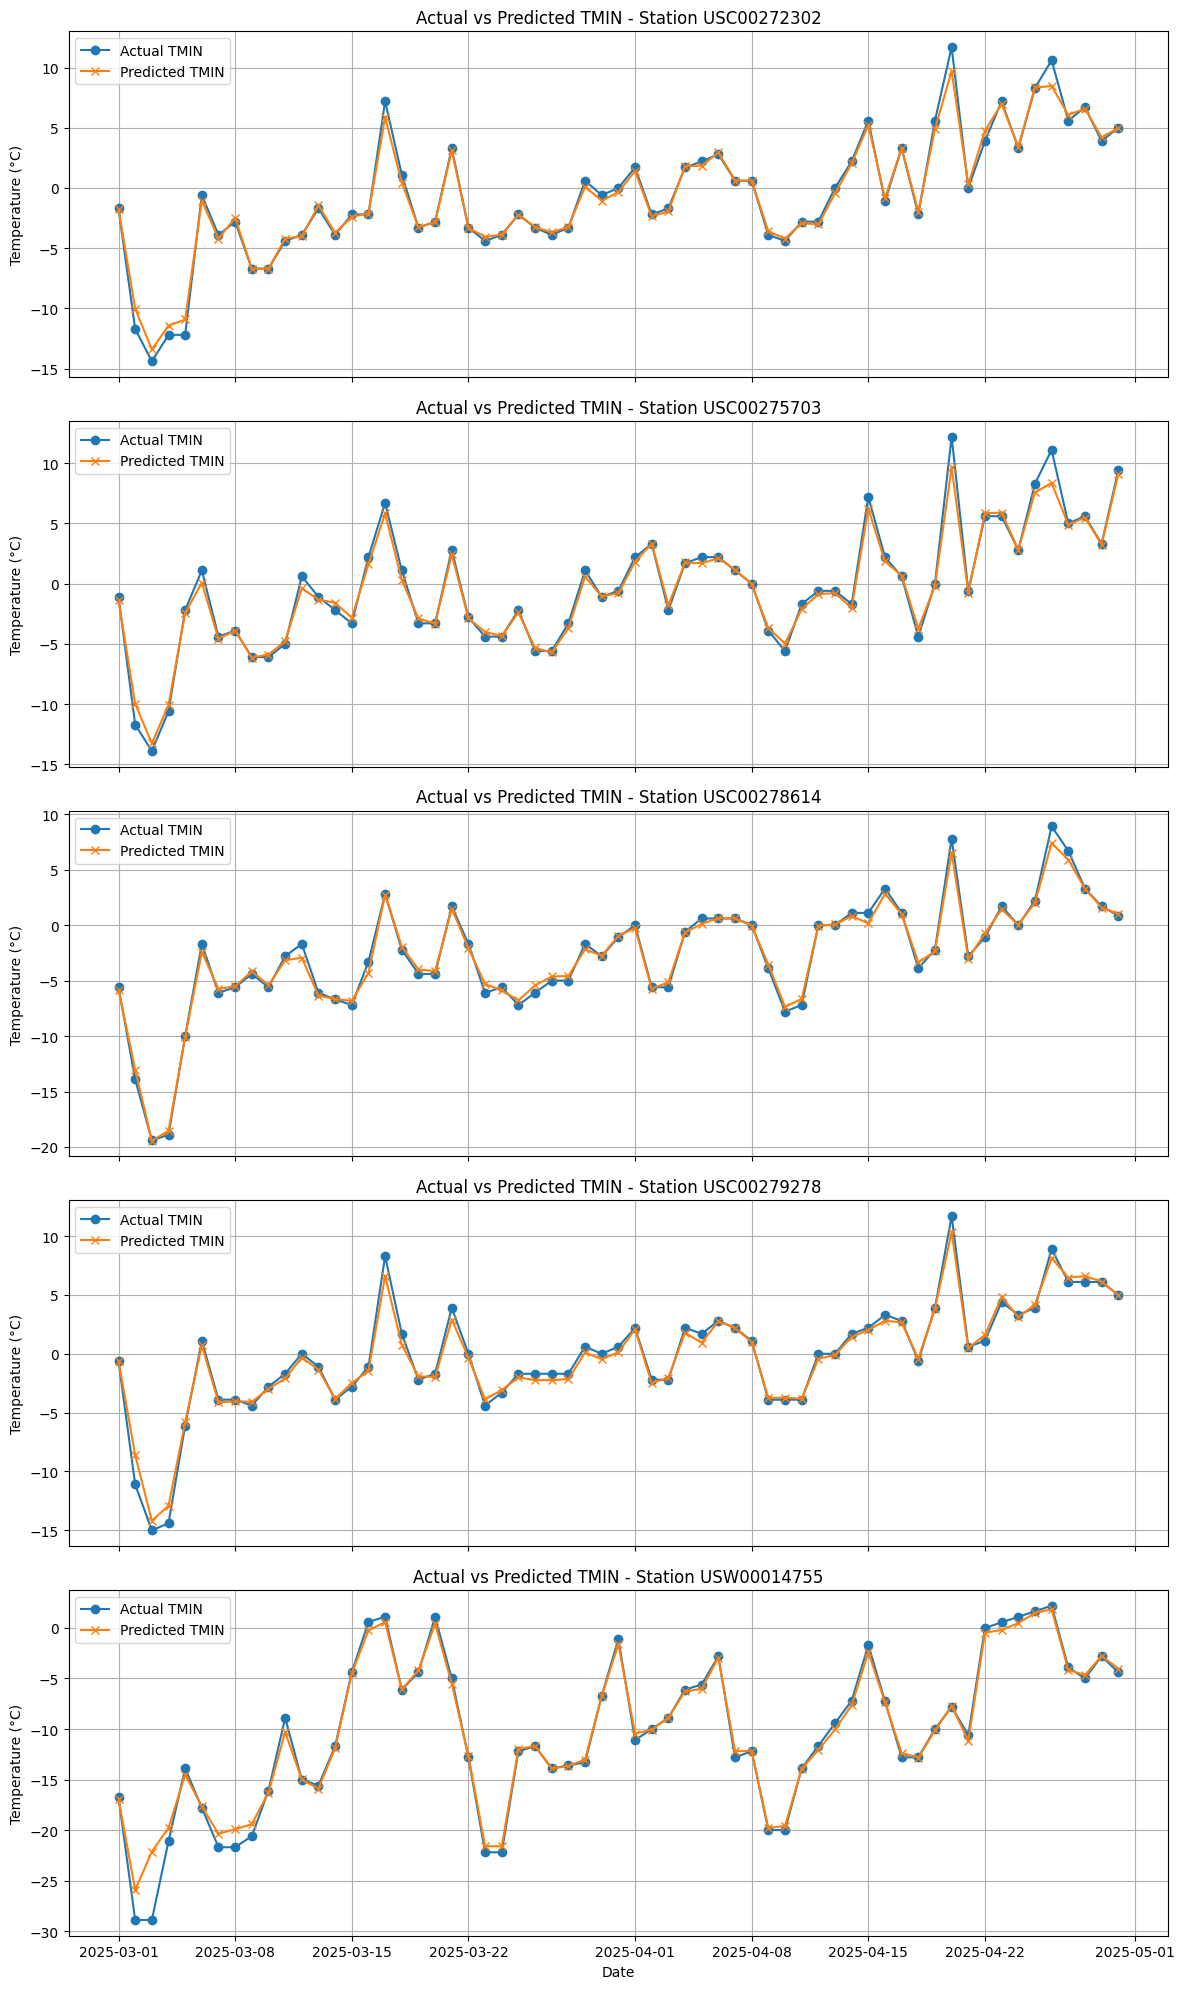

In [54]:
import matplotlib.pyplot as plt

# Get list of unique stations
stations = merged_march_april_df['Station_ID'].unique()

# Setup Subplots
n_stations = len(stations)
fig, axs = plt.subplots(n_stations, 1, figsize=(12, 4 * n_stations), sharex=True)

if n_stations == 1:
    axs = [axs]  # Make it iterable if only one station

for ax, station in zip(axs, stations):
    station_data = merged_march_april_df[merged_march_april_df['Station_ID'] == station]
    ax.plot(station_data['DATE'], station_data['Actual_TMIN'], label='Actual TMIN', marker='o')
    ax.plot(station_data['DATE'], station_data['Predicted_TMIN'], label='Predicted TMIN', marker='x')
    ax.set_title(f"Actual vs Predicted TMIN - Station {station}")
    ax.set_ylabel("Temperature (°C)")
    ax.grid(True)
    ax.legend()

plt.xlabel("Date")
plt.tight_layout()
plt.show()


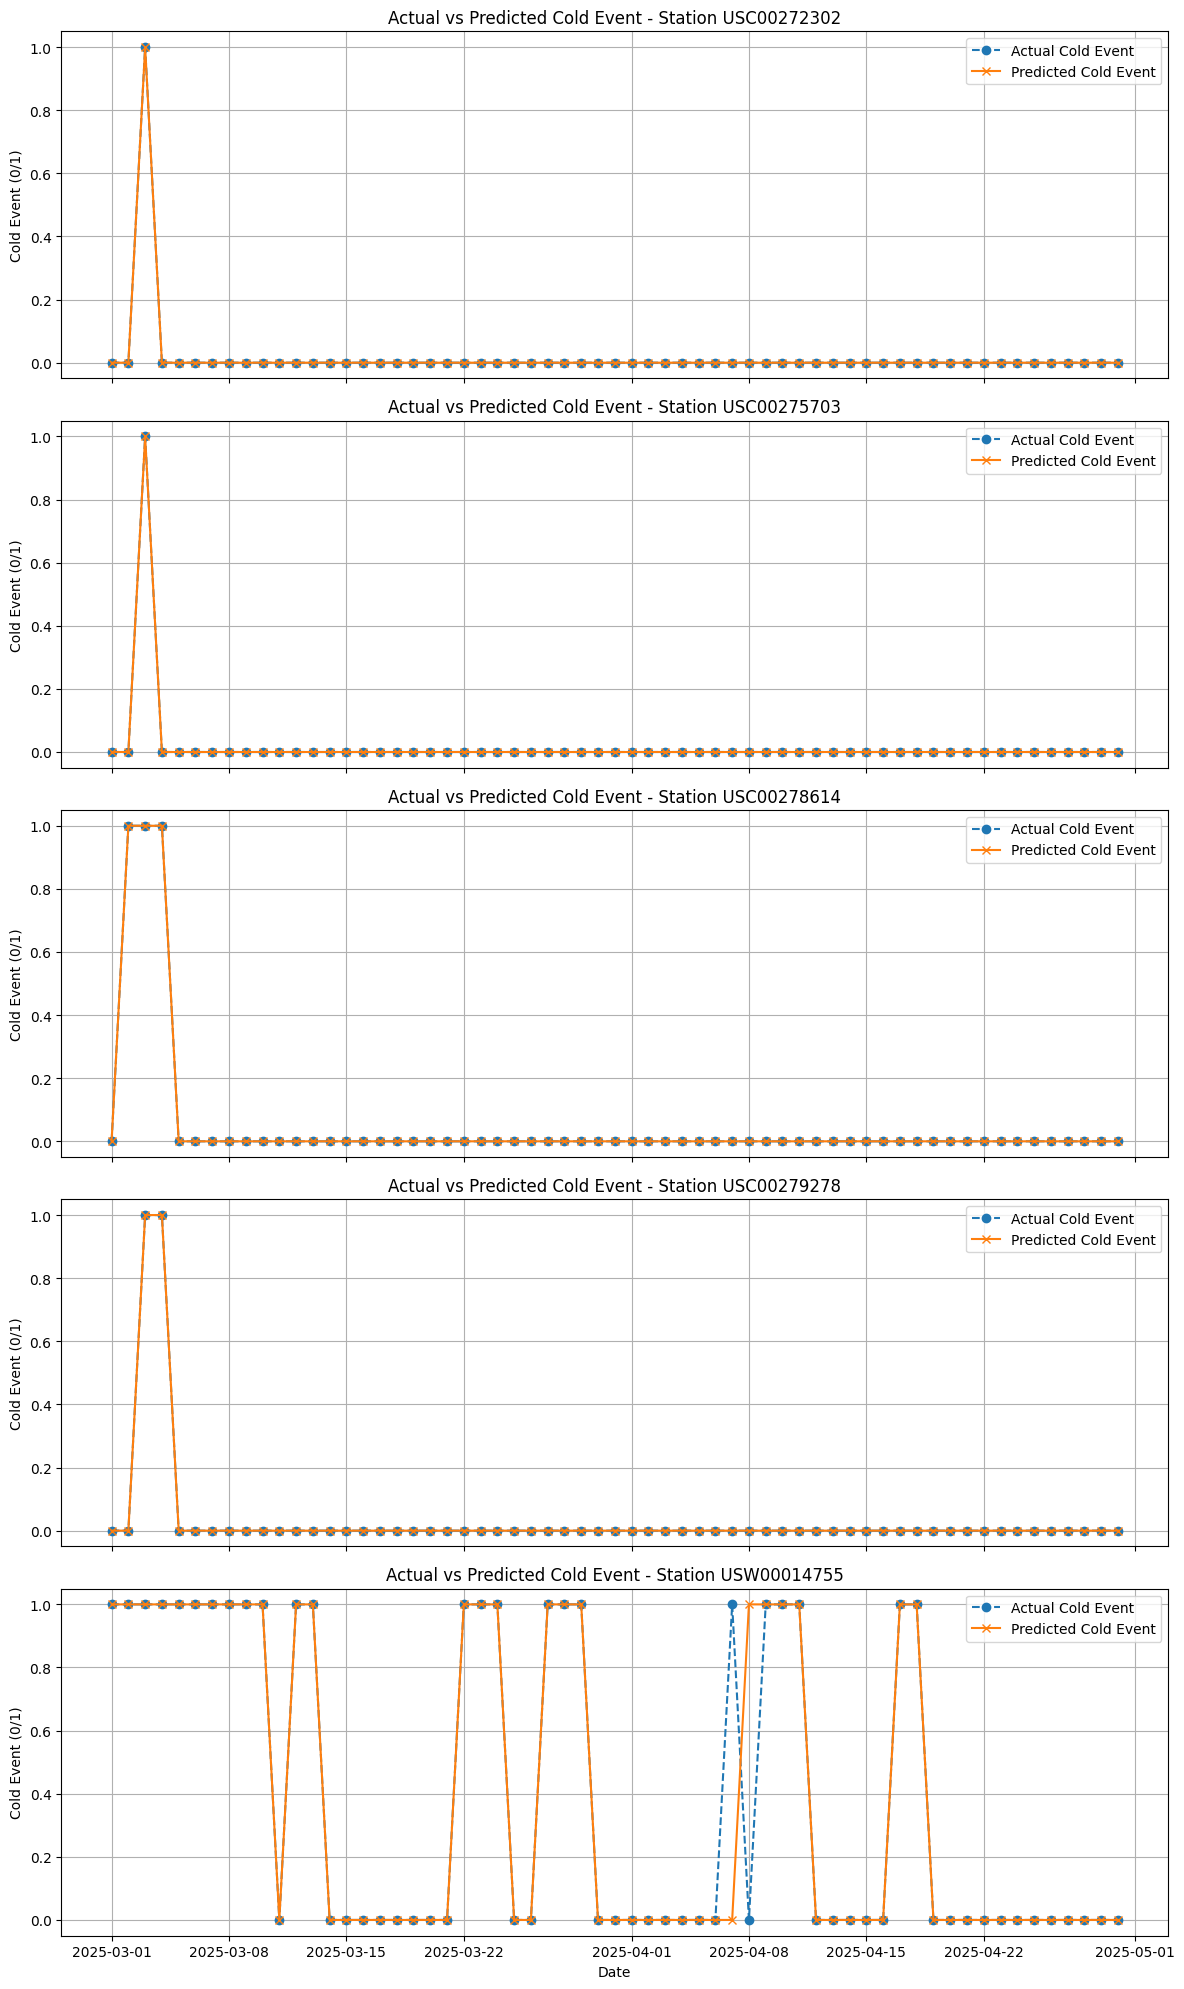

In [55]:
fig, axs = plt.subplots(n_stations, 1, figsize=(12, 4 * n_stations), sharex=True)

if n_stations == 1:
    axs = [axs]

for ax, station in zip(axs, stations):
    station_data = merged_march_april_df[merged_march_april_df['Station_ID'] == station]
    ax.plot(station_data['DATE'], station_data['Actual_Cold_Event'], label='Actual Cold Event', linestyle='--', marker='o')
    ax.plot(station_data['DATE'], station_data['Cold_Event'], label='Predicted Cold Event', linestyle='-', marker='x')
    ax.set_title(f"Actual vs Predicted Cold Event - Station {station}")
    ax.set_ylabel("Cold Event (0/1)")
    ax.grid(True)
    ax.legend()

plt.xlabel("Date")
plt.tight_layout()
plt.show()


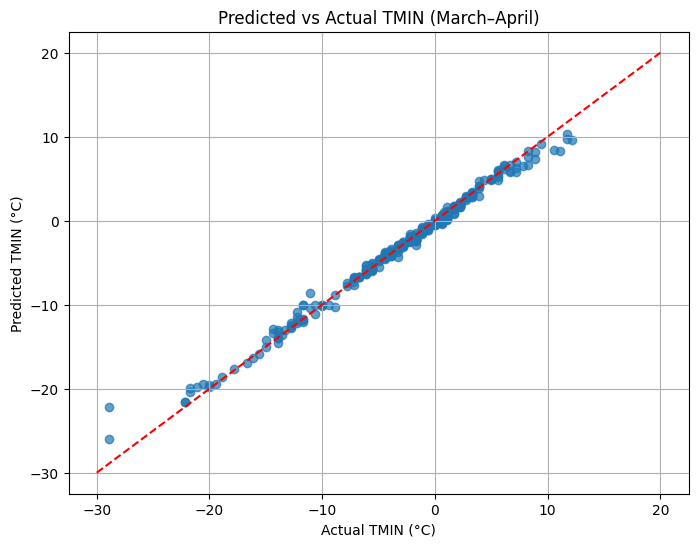

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(merged_march_april_df['Actual_TMIN'], merged_march_april_df['Predicted_TMIN'], alpha=0.7)
plt.plot([-30, 20], [-30, 20], color='red', linestyle='--')  # Ideal line
plt.title('Predicted vs Actual TMIN (March–April)')
plt.xlabel('Actual TMIN (°C)')
plt.ylabel('Predicted TMIN (°C)')
plt.grid(True)
plt.show()

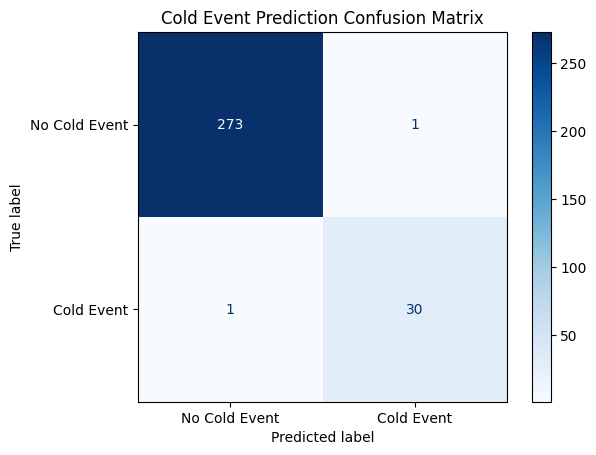

In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion matrix
cm = confusion_matrix(merged_march_april_df['Actual_Cold_Event'], merged_march_april_df['Cold_Event'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Cold Event", "Cold Event"])
disp.plot(cmap='Blues')
plt.title('Cold Event Prediction Confusion Matrix')
plt.show()


In [56]:
# 1. Ensure DATE column is datetime
future_features_df['DATE'] = pd.to_datetime(future_features_df['DATE'])

# 2. Filter between 2025-01-01 and 2025-02-28
mask_nh = (future_features_df['DATE'] >= '2025-01-01') & (future_features_df['DATE'] <= '2025-02-28')
jan_feb_nh_df = future_features_df.loc[mask_nh]

# 3. Save New Hampshire data
jan_feb_nh_df[['DATE', 'Station_ID', 'Predicted_TMIN', 'TMIN']].rename(columns={'TMIN': 'Actual_TMIN'}).to_csv('NewHampshire_Predicted_Actual_JanFeb2025.csv', index=False)

print("✅ New Hampshire Jan-Feb 2025 Predicted vs Actual TMIN saved to NewHampshire_Predicted_Actual_JanFeb2025.csv")


✅ New Hampshire Jan-Feb 2025 Predicted vs Actual TMIN saved to NewHampshire_Predicted_Actual_JanFeb2025.csv
